# ResNet1D RF Modulation Classification

## Approach
MATLAB signal → Normalize I/Q → 1D ResNet

## Key Advantages
- No CWT computation (much faster preprocessing)
- Smaller model (~2.5M params vs 11M for ResNet18)
- 3-4x faster training
- Direct learning from raw I/Q samples

## Section 1: Setup and Imports

In [8]:
# Clear GPU memory before starting 
import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    print(f"GPU memory freed. Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("CUDA not available, using CPU")

GPU memory freed. Available: 8.6 GB


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matlab.engine
import time
from pathlib import Path
import sys
import json

# NOTE: ResNet1D classes defined inline later (no external import needed)

%matplotlib inline

# Set seeds
np.random.seed(42)
torch.manual_seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Section 2: MATLAB Signal Generation

In [10]:
# Start MATLAB engine
print("Starting MATLAB engine...")
eng = matlab.engine.start_matlab()
print("MATLAB ready!")

modulations = ['BPSK', 'QPSK', '8PSK', '16QAM', '64QAM', '4FSK', 'OFDM']

Starting MATLAB engine...
MATLAB ready!


In [11]:
def generate_signal(eng, mod_type, snr_db=10, num_symbols=1000):
    """
    Generate modulated signal with Pulse Shaping (RRC) for PSK/QAM
    to create realistic time-domain waveforms.
    """
    # Common params for Pulse Shaping
    eng.eval("sps = 8;", nargout=0)  # Samples per symbol (Oversampling)
    eng.eval("rolloff = 0.35;", nargout=0)
    eng.eval("span = 10;", nargout=0)
    eng.eval("rrcFilter = rcosdesign(rolloff, span, sps);", nargout=0)

    if mod_type == 'BPSK':
        eng.eval(f"data = randi([0 1], {num_symbols}, 1);", nargout=0)
        eng.eval("mod_sig = pskmod(data, 2);", nargout=0)
        # Apply Pulse Shaping to turn dots into wave
        eng.eval("tx = upfirdn(mod_sig, rrcFilter, sps);", nargout=0)
    
    elif mod_type == 'QPSK':
        eng.eval(f"data = randi([0 3], {num_symbols}, 1);", nargout=0)
        eng.eval("mod_sig = pskmod(data, 4, pi/4);", nargout=0)
        eng.eval("tx = upfirdn(mod_sig, rrcFilter, sps);", nargout=0)
    
    elif mod_type == '8PSK':
        eng.eval(f"data = randi([0 7], {num_symbols}, 1);", nargout=0)
        eng.eval("mod_sig = pskmod(data, 8);", nargout=0)
        eng.eval("tx = upfirdn(mod_sig, rrcFilter, sps);", nargout=0)
    
    elif mod_type == '16QAM':
        eng.eval(f"data = randi([0 15], {num_symbols}, 1);", nargout=0)
        eng.eval("mod_sig = qammod(data, 16, 'UnitAveragePower', true);", nargout=0)
        eng.eval("tx = upfirdn(mod_sig, rrcFilter, sps);", nargout=0)
    
    elif mod_type == '64QAM':
        eng.eval(f"data = randi([0 63], {num_symbols}, 1);", nargout=0)
        eng.eval("mod_sig = qammod(data, 64, 'UnitAveragePower', true);", nargout=0)
        eng.eval("tx = upfirdn(mod_sig, rrcFilter, sps);", nargout=0)
    
    elif mod_type == '4FSK':
        # FSK is already a waveform (nsamp=16), no change needed
        eng.eval("M = 4; nsamp = 16; freq_sep = 50; Fs_fsk = 1000;", nargout=0)
        eng.eval(f"data = randi([0 M-1], {num_symbols//16}, 1);", nargout=0)
        eng.eval("tx = fskmod(data, M, freq_sep, nsamp, Fs_fsk);", nargout=0)
    
    elif mod_type == 'OFDM':
        # OFDM is already a waveform, no change needed
        eng.eval("ofdm_mod = comm.OFDMModulator('FFTLength', 64, 'CyclicPrefixLength', 16);", nargout=0)
        eng.eval("ofdm_info = info(ofdm_mod);", nargout=0)
        eng.eval("num_carriers = ofdm_info.DataInputSize(1);", nargout=0)
        eng.eval(f"num_symbols = {num_symbols // 80};", nargout=0)
        eng.eval("tx = [];", nargout=0)
        eng.eval("for k = 1:num_symbols; d = pskmod(randi([0 3], num_carriers, 1), 4, pi/4); tx = [tx; ofdm_mod(d)]; end", nargout=0)
    
    # Add noise
    eng.eval(f"rx = awgn(tx, {snr_db}, 'measured');", nargout=0)
    
    # Get signal
    rx = np.array(eng.workspace['rx']).flatten()
    return rx

## Section 3: 1D Preprocessing

In [12]:
def prepare_1d_signal(signal, target_length=2048):
    """
    Fixed: Normalizes by Global Power to preserve constellation shape.
    """
    # 1. Truncate/Pad
    if len(signal) > target_length:
        signal = signal[:target_length]
    elif len(signal) < target_length:
        signal = np.pad(signal, (0, target_length - len(signal)), mode='constant')
    
    # 2. Extract I/Q
    I = signal.real
    Q = signal.imag
    
    # 3. Normalization 
    # Calculate power of the complex signal, not individual channels
    power = np.sqrt(np.mean(I**2 + Q**2))
    
    # Avoid division by zero
    if power < 1e-10: 
        power = 1e-10
        
    I = I / power
    Q = Q / power
    
    # Stack
    return np.stack([I, Q], axis=0).astype(np.float32)

## Section 4: Visualize Sample Signals

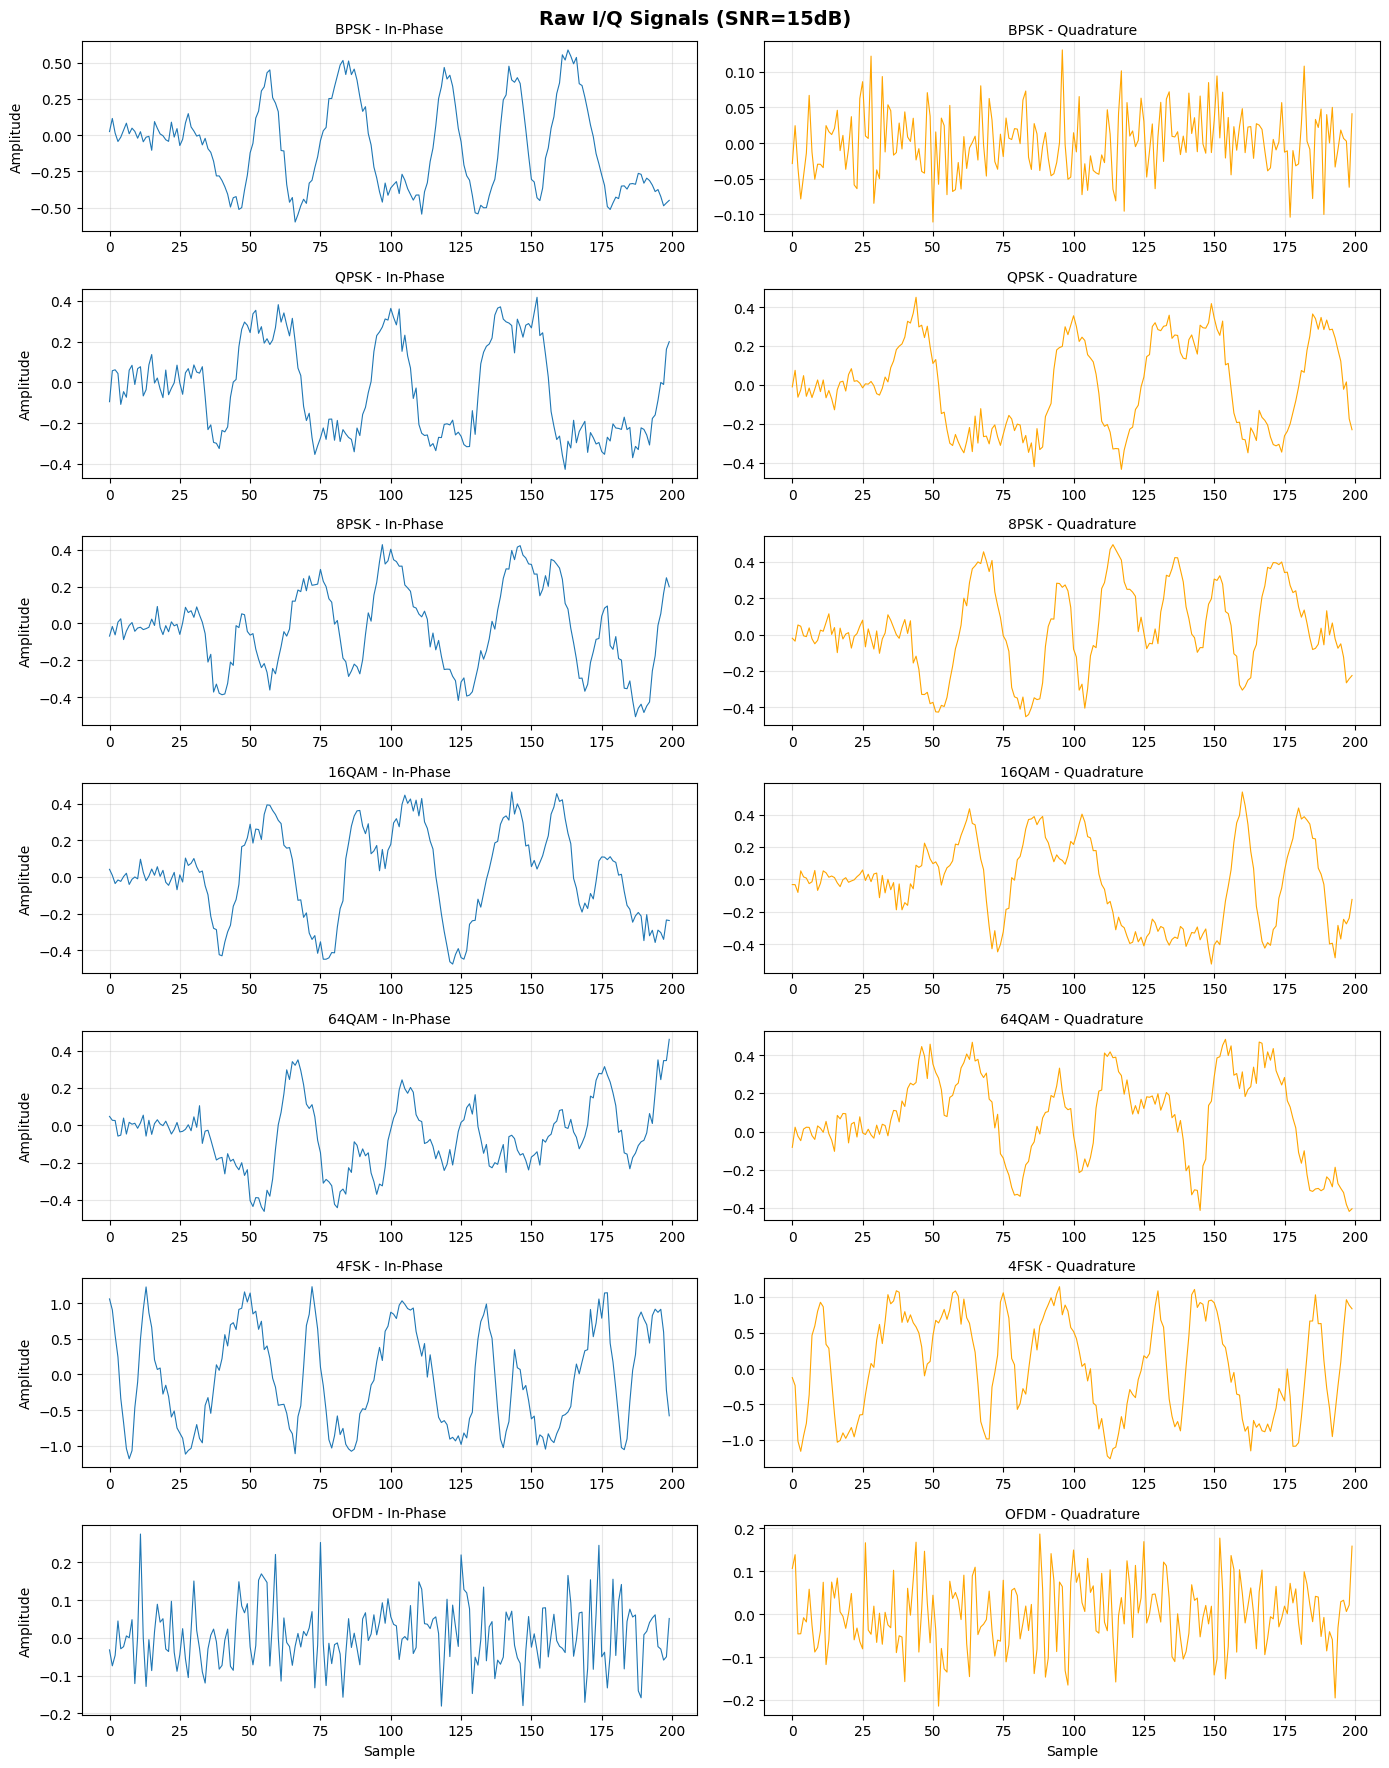

In [13]:
# Generate and visualize test signals
fig, axes = plt.subplots(len(modulations), 2, figsize=(14, 18))

for idx, mod in enumerate(modulations):
    signal = generate_signal(eng, mod, snr_db=15, num_symbols=1000)
    
    # Plot I (real) component
    axes[idx, 0].plot(signal[:200].real, linewidth=0.8)
    axes[idx, 0].set_title(f'{mod} - In-Phase', fontsize=10)
    axes[idx, 0].set_ylabel('Amplitude')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Plot Q (imaginary) component
    axes[idx, 1].plot(signal[:200].imag, linewidth=0.8, color='orange')
    axes[idx, 1].set_title(f'{mod} - Quadrature', fontsize=10)
    axes[idx, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel('Sample')
axes[-1, 1].set_xlabel('Sample')
plt.suptitle('Raw I/Q Signals (SNR=15dB)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 5: Dataset Class

In [14]:
class Signal1DDataset(Dataset):
    def __init__(self, signals, labels):
        """
        signals: numpy array of shape [N, 2, L] (2 channels: I and Q)
        labels: numpy array of shape [N]
        """
        self.signals = signals
        self.labels = labels
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        signal = self.signals[idx]
        label = self.labels[idx]
        
        return torch.from_numpy(signal).float(), torch.tensor(label, dtype=torch.long)

## Section 6: Generate Dataset

In [15]:
NUM_SAMPLES_PER_CLASS = 1000
SIGNAL_LENGTH = 2048

print(f"Generating dataset: {NUM_SAMPLES_PER_CLASS} samples/class...")
print(f"Total samples: {NUM_SAMPLES_PER_CLASS * len(modulations)}")

# Storage
signals_1d = []
labels = []

start_time = time.time()

for label_idx, mod in enumerate(modulations):
    print(f"  {mod}...")
    
    for i in range(NUM_SAMPLES_PER_CLASS):
        if i % 100 == 0 and i > 0:
            elapsed = time.time() - start_time
            print(f"    {i}/{NUM_SAMPLES_PER_CLASS}... (elapsed: {elapsed:.1f}s)")
        
        # Random SNR between -5 and 20 dB
        # snr = np.random.uniform(-5, 20) maybe -5 was a bit too ambitious 
        snr = np.random.uniform(-5, 20)

        # Generate signal
        signal = generate_signal(eng, mod, snr_db=snr, num_symbols=1000)
        
        # 1D preprocessing
        sig_1d = prepare_1d_signal(signal, target_length=SIGNAL_LENGTH)
        signals_1d.append(sig_1d)
        
        labels.append(label_idx)

total_time = time.time() - start_time

# Convert to arrays
signals_1d = np.array(signals_1d, dtype=np.float32)
labels = np.array(labels, dtype=np.int64)

print(f"\n✅ Dataset generated in {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"1D signals shape: {signals_1d.shape}")
print(f"Labels shape: {labels.shape}")

Generating dataset: 1000 samples/class...
Total samples: 7000
  BPSK...
    100/1000... (elapsed: 1.6s)
    200/1000... (elapsed: 3.3s)
    300/1000... (elapsed: 4.9s)
    400/1000... (elapsed: 6.3s)
    500/1000... (elapsed: 7.8s)
    600/1000... (elapsed: 9.2s)
    700/1000... (elapsed: 10.6s)
    800/1000... (elapsed: 12.2s)
    900/1000... (elapsed: 13.6s)
  QPSK...
    100/1000... (elapsed: 16.5s)
    200/1000... (elapsed: 18.1s)
    300/1000... (elapsed: 19.9s)
    400/1000... (elapsed: 21.5s)
    500/1000... (elapsed: 23.1s)
    600/1000... (elapsed: 24.8s)
    700/1000... (elapsed: 26.4s)
    800/1000... (elapsed: 28.2s)
    900/1000... (elapsed: 29.8s)
  8PSK...
    100/1000... (elapsed: 33.1s)
    200/1000... (elapsed: 34.6s)
    300/1000... (elapsed: 36.5s)
    400/1000... (elapsed: 38.4s)
    500/1000... (elapsed: 40.4s)
    600/1000... (elapsed: 42.3s)
    700/1000... (elapsed: 43.9s)
    800/1000... (elapsed: 45.4s)
    900/1000... (elapsed: 46.9s)
  16QAM...
    100/1000

In [16]:
# Check class balance
class_counts = np.bincount(labels)
print("Class distribution:")
for mod, count in zip(modulations, class_counts):
    print(f"  {mod}: {count} samples ({count/len(labels)*100:.1f}%)")

Class distribution:
  BPSK: 1000 samples (14.3%)
  QPSK: 1000 samples (14.3%)
  8PSK: 1000 samples (14.3%)
  16QAM: 1000 samples (14.3%)
  64QAM: 1000 samples (14.3%)
  4FSK: 1000 samples (14.3%)
  OFDM: 1000 samples (14.3%)


## Section 7: Train/Val Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    signals_1d, labels, test_size=0.2, stratify=labels, random_state=42
)

print(f"Training: {X_train.shape}, Validation: {X_val.shape}")

Training: (5600, 2, 2048), Validation: (1400, 2, 2048)


In [18]:
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew

def get_signal_features(X_data, y_data, labels_map):
    """
    Extracts statistical fingerprints from I/Q data.
    X_data: (N, 2, 2048)
    y_data: (N,)
    """
    features = []
    
    indices = np.random.choice(len(X_data), 500, replace=False)
    
    for idx in indices:
        sig = X_data[idx] # Shape (2, 2048)
        
        # Reconstruct complex signal for easier math
        complex_sig = sig[0] + 1j * sig[1]
        
        # 1. Amplitude Statistics
        amp = np.abs(complex_sig)
        papr = np.max(amp**2) / np.mean(amp**2) # Peak-to-Average Power Ratio
        
        # 2. Higher Order Statistics (The "Gold Standard" for Modulation)
        # C42 (4th order cumulant) is great for separating QAM from PSK
        m4 = np.mean(complex_sig**4)
        m2 = np.mean(complex_sig**2)
        c42 = np.mean(np.abs(complex_sig)**4) - np.abs(m2)**2 - 2 * np.mean(np.abs(complex_sig)**2)**2

        features.append({
            'Label': labels_map[y_data[idx]],
            'PAPR': papr,
            'Kurtosis_Real': kurtosis(sig[0]),
            'Kurtosis_Imag': kurtosis(sig[1]),
            'C42': np.abs(c42) 
        })
        
    df = pd.DataFrame(features)
    
    # Group by label to see the "fingerprint" of each modulation
    summary = df.groupby('Label').mean().round(4)
    return summary

# Map numeric labels back to names
label_names = ['BPSK', 'QPSK', '8PSK', '16QAM', '64QAM', '4FSK', 'OFDM']
summary_table = get_signal_features(X_train, y_train, label_names)

print(summary_table.to_markdown())

| Label   |    PAPR |   Kurtosis_Real |   Kurtosis_Imag |    C42 |
|:--------|--------:|----------------:|----------------:|-------:|
| 16QAM   |  5.374  |         -0.643  |         -0.641  | 0.3182 |
| 4FSK    |  7.8187 |          1.2539 |          1.2339 | 0.8321 |
| 64QAM   |  5.5355 |         -0.5951 |         -0.6078 | 0.2916 |
| 8PSK    |  4.8965 |         -0.6763 |         -0.6677 | 0.4552 |
| BPSK    |  5.1715 |         -1.083  |          0.0025 | 0.9198 |
| OFDM    | 15.5261 |          3.2783 |          3.3258 | 2.2111 |
| QPSK    |  4.6086 |         -1.0003 |         -1.0175 | 0.4982 |


## Section 7.5: OPTIMIZATION ADDITIONS - Advanced Augmentation & Architecture

This section defines essential classes for improved performance:
- `IQAugmentation` - Advanced data augmentation for RF signals
- `ResNet1DOptimized` - Enhanced model architecture with SE attention
- `Signal1DDatasetAugmented` - Dataset class with augmentation support
- `train_optimized` - Training function with AMP and better scheduling
- `evaluate_with_tta` - Test-time augmentation for accuracy boost

In [19]:
# ============================================
# PART 2: OPTIMIZED RESNET1D ARCHITECTURE
# ============================================

def get_num_groups(num_channels, max_groups=8):
    """Get a valid number of groups that divides num_channels."""
    for g in range(min(max_groups, num_channels), 0, -1):
        if num_channels % g == 0:
            return g
    return 1

class SEBlock1D(nn.Module):
    """Squeeze-Excitation attention block"""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool1d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, max(channels//reduction, 4), bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(max(channels//reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1)
        return x * y

class ResBlock1D(nn.Module):
    """Enhanced residual block with SE attention and GroupNorm"""
    def __init__(self, in_ch, out_ch, kernel_size, stride, downsample, dropout=0.1):
        super().__init__()
        num_groups = get_num_groups(out_ch, max_groups=32)
        padding = (kernel_size - 1) // 2
        
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride, padding, bias=False)
        self.gn1 = nn.GroupNorm(num_groups, out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, 1, padding, bias=False)
        self.gn2 = nn.GroupNorm(num_groups, out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.se = SEBlock1D(out_ch)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None
    
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.gn1(out)
        out = self.relu(out)
        
        if self.dropout:
            out = self.dropout(out)
        
        out = self.conv2(out)
        out = self.gn2(out)
        out = self.se(out)
        
        if self.downsample:
            identity = self.downsample(x)
        
        # FIX: Ensure sizes match exactly (handles rounding issues with stride)
        if out.size(-1) != identity.size(-1):
            identity = nn.functional.adaptive_avg_pool1d(identity, out.size(-1))
        
        out += identity
        return self.relu(out)

class MultiScaleInput(nn.Module):
    """Multi-scale feature extraction with different kernel sizes"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        branch_ch = out_ch // 4
        num_groups = get_num_groups(branch_ch, max_groups=8)
        
        self.b1 = nn.Sequential(
            nn.Conv1d(in_ch, branch_ch, 3, padding=1),
            nn.GroupNorm(num_groups, branch_ch),
            nn.ReLU()
        )
        self.b2 = nn.Sequential(
            nn.Conv1d(in_ch, branch_ch, 7, padding=3),
            nn.GroupNorm(num_groups, branch_ch),
            nn.ReLU()
        )
        self.b3 = nn.Sequential(
            nn.Conv1d(in_ch, branch_ch, 15, padding=7),
            nn.GroupNorm(num_groups, branch_ch),
            nn.ReLU()
        )
        self.b4 = nn.Sequential(
            nn.AvgPool1d(3, 1, 1),
            nn.Conv1d(in_ch, branch_ch, 1),
            nn.GroupNorm(num_groups, branch_ch),
            nn.ReLU()
        )
    
    def forward(self, x):
        return torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x)], dim=1)

class ResNet1DOptimized(nn.Module):
    """Optimized ResNet1D with attention and multi-scale features"""
    def __init__(self, in_ch=2, base_filters=64, kernel_size=16, stride=2, n_block=10, n_classes=7, dropout=0.2):
        super().__init__()
        
        # Multi-scale input
        self.input_layer = MultiScaleInput(in_ch, base_filters)
        
        # Residual blocks - only downsample in first few blocks to avoid shrinking too small
        # With stride=2, max ~6 downsamples for 2048 input: 2048→1024→512→256→128→64→32
        max_downsample_blocks = 6  # After this, use stride=1
        
        self.layers = nn.ModuleList()
        in_filters = base_filters
        
        for i in range(n_block):
            out_filters = base_filters * (2 ** (i // 3))  # Double every 3 blocks
            out_filters = min(out_filters, 256)  # Cap at 256
            
            # Only use stride=2 for first max_downsample_blocks, then stride=1
            block_stride = stride if i < max_downsample_blocks else 1
            
            # Downsample if stride > 1 or channel change
            downsample = None
            if block_stride != 1 or in_filters != out_filters:
                ds_num_groups = get_num_groups(out_filters, max_groups=32)
                downsample = nn.Sequential(
                    nn.Conv1d(in_filters, out_filters, 1, block_stride, bias=False),
                    nn.GroupNorm(ds_num_groups, out_filters)
                )
            
            self.layers.append(ResBlock1D(in_filters, out_filters, kernel_size, block_stride, downsample, dropout))
            in_filters = out_filters
        
        # Global pooling and classifier
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(in_filters, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout/2),
            nn.Linear(128, n_classes)
        )
    
    def forward(self, x):
        x = self.input_layer(x)
        for layer in self.layers:
            x = layer(x)
        x = self.gap(x)
        return self.classifier(x)

modulations

# Quick test
test_input = torch.randn(4, 2, SIGNAL_LENGTH).to(device)
test_model = ResNet1DOptimized(n_classes=len(modulations)).to(device)
test_output = test_model(test_input)
print(f"Test output shape: {test_output.shape}")
print(f"Model params: {sum(p.numel() for p in test_model.parameters()):,}")
del test_model, test_input, test_output
torch.cuda.empty_cache()

Test output shape: torch.Size([4, 7])
Model params: 9,868,679


In [20]:
# experimental: DCCBlock from RFML book

class DCCBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation, dropout=0.1):
        super().__init__()
        # Causal padding: pad only on the left so we never see future samples
        self.causal_pad = (kernel_size - 1) * dilation  # left-only padding

        # Two parallel conv paths for the gated activation (filter and gate)
        # We use one conv with 2x output channels and then split it — 
        # equivalent but more efficient than two separate convs
        self.conv_fg = nn.Conv1d(
            channels, channels * 2,
            kernel_size=kernel_size,
            dilation=dilation,
            padding=0,   # we handle padding manually for causality
            bias=False
        )
        num_groups = get_num_groups(channels, max_groups=32)
        self.gn = nn.GroupNorm(num_groups, channels * 2)

        # 1x1 conv applied after gated activation (as in the book's architecture)
        self.conv_1x1 = nn.Conv1d(channels, channels, kernel_size=1, bias=False)

        self.dropout = nn.Dropout(dropout) if dropout > 0 else None

    def forward(self, x):
        # Causal padding: prepend zeros on the left only
        out = F.pad(x, (self.causal_pad, 0))
        out = self.conv_fg(out)
        out = self.gn(out)

        # Split into filter and gate halves
        f, g = out.chunk(2, dim=1)

        # Gated activation: z = tanh(Wf * x) ⊙ σ(Wg * x)
        out = torch.tanh(f) * torch.sigmoid(g)

        if self.dropout:
            out = self.dropout(out)

        out = self.conv_1x1(out)

        # Residual connection (input added back to output)
        residual = out + x

        # Skip connection output (returned separately for accumulation)
        return residual, out
    
    
class DCCNet(nn.Module):
    def __init__(self, in_ch=2, channels=64, kernel_size=8, n_block=10, n_classes=7, dropout=0.2):
        super().__init__()

        # Simple input projection to get to `channels` dims
        # (you could keep MultiScaleInput here as a stem if you want)
        self.input_proj = nn.Sequential(
            nn.Conv1d(in_ch, channels, kernel_size=1),
            nn.GroupNorm(get_num_groups(channels), channels),
            nn.ReLU()
        )

        # Build DCC blocks with exponentially increasing dilation
        # Pattern: 1, 2, 4, 8, 16, 32, ... repeating if n_block > log2 range
        self.blocks = nn.ModuleList()
        for i in range(n_block):
            dilation = 2 ** (i % 10)  # cycles: 1,2,4,...512,1,2,...
            self.blocks.append(DCCBlock(channels, kernel_size, dilation, dropout))

        # Sum of skips → ReLU → 1x1 → ReLU → 1x1 (standard WaveNet output stack)
        self.output_stack = nn.Sequential(
            nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size=1),
        )

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(channels, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.input_proj(x)

        skip_sum = 0
        for block in self.blocks:
            x, skip = block(x)
            skip_sum = skip_sum + skip  # accumulate skips across all blocks

        out = self.output_stack(skip_sum)
        out = self.gap(out)
        return self.classifier(out)

In [21]:
import time
from torch.cuda.amp import GradScaler, autocast

def train_dcc(
    model, train_loader, val_loader,
    num_epochs=100, lr=3e-4, weight_decay=1e-3,
    warmup=10, patience=20,
    grad_accum_steps=4   # NEW: accumulate gradients to compensate for smaller effective batch
):
    model = model.to(device)
    scaler = GradScaler(enabled=torch.cuda.is_available())

    # Separate weight decay: apply to conv/linear weights only, not norm/bias
    # This matters more for DCCNet because the gating params are sensitive to over-regularization
    decay_params = [p for n, p in model.named_parameters()
                    if p.requires_grad and p.dim() >= 2]
    nodecay_params = [p for n, p in model.named_parameters()
                      if p.requires_grad and p.dim() < 2]
    optimizer = optim.AdamW([
        {'params': decay_params,   'weight_decay': weight_decay},
        {'params': nodecay_params, 'weight_decay': 0.0}
    ], lr=lr)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # OneCycleLR works better than CosineAnnealing for DCC:
    # the aggressive LR rise helps escape flat regions caused by the
    # gated activation (tanh * sigmoid saturates easily at init)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr,
        epochs=num_epochs,
        steps_per_epoch=max(1, len(train_loader) // grad_accum_steps),
        pct_start=warmup / num_epochs,   # warmup fraction
        div_factor=25,                   # initial lr = max_lr / 25
        final_div_factor=1e4,
        anneal_strategy='cos'
    )

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': [], 'epoch_times': []}
    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0

    for epoch in range(num_epochs):
        start = time.time()

        # ── Train ──────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()

        for step, (inputs, targets) in enumerate(train_loader):
            inputs  = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            with autocast(enabled=torch.cuda.is_available()):
                outputs = model(inputs)
                # Scale loss by accumulation steps so gradients are
                # equivalent to a single large-batch backward pass
                loss = criterion(outputs, targets) / grad_accum_steps

            scaler.scale(loss).backward()
            train_loss += loss.item() * grad_accum_steps * inputs.size(0)

            # Only step optimizer every grad_accum_steps batches
            if (step + 1) % grad_accum_steps == 0:
                scaler.unscale_(optimizer)
                # DCC gating can produce large gradients at init — keep clip tight
                torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()

        # Handle leftover steps that didn't complete a full accumulation cycle
        if (len(train_loader)) % grad_accum_steps != 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_loss /= len(train_loader.dataset)

        # ── Validate ───────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs  = inputs.to(device)
                targets = targets.to(device)

                with autocast(enabled=torch.cuda.is_available()):
                    outputs = model(inputs)
                    loss    = criterion(outputs, targets)

                val_loss += loss.item() * inputs.size(0)
                _, preds  = outputs.max(1)
                correct  += preds.eq(targets).sum().item()
                total    += targets.size(0)

        val_loss /= total
        val_acc   = 100.0 * correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        history['epoch_times'].append(time.time() - start)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train: {train_loss:.4f}, Val: {val_loss:.4f}, "
                  f"Acc: {val_acc:.2f}%, "
                  f"LR: {optimizer.param_groups[0]['lr']:.6f}, "
                  f"Time: {history['epoch_times'][-1]:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f"  ✓ Best: {val_acc:.2f}%")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if best_model_state:
        model.load_state_dict(best_model_state)

    return history, best_val_acc

In [ ]:
from torch.utils.data import DataLoader, TensorDataset


In [25]:
# 1. DataLoaders — reduce batch size due to larger activations
batch_size = 16  # down from 64; DCCNet has no downsampling so activations stay large

train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
val_ds   = TensorDataset(torch.FloatTensor(X_val),   torch.LongTensor(y_val))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# 2. Initialize DCCNet instead
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dcc = DCCNet(
    in_ch=2,
    channels=64,
    kernel_size=8,
    n_block=10,
    n_classes=7,
    dropout=0.3
).to(device)

# 3. Train
print(f"Starting DCC training on {device}...")
history, best_acc = train_dcc(
    model_dcc,
    train_loader,
    val_loader,
    num_epochs=60,        # more epochs — gated activations are slower to converge
    lr=3e-4,              # lower than your ResNet lr=0.001
    warmup=10,            # longer warmup for the same reason
    grad_accum_steps=4    # effective batch = 16 * 4 = 64, matching your original
)

# 4. Save
torch.save(model_dcc.state_dict(), "best_dcc_model.pth")

Starting DCC training on cuda...


C:\Users\madan\AppData\Local\Temp\ipykernel_33544\1898088670.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())
C:\Users\madan\AppData\Local\Temp\ipykernel_33544\1898088670.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
C:\Users\madan\AppData\Local\Temp\ipykernel_33544\1898088670.py:97: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


  ✓ Best: 16.21%
  ✓ Best: 42.43%
  ✓ Best: 43.00%
  ✓ Best: 68.79%
Epoch [5/60] Train: 1.1605, Val: 1.0394, Acc: 78.64%, LR: 0.000156, Time: 20.2s
  ✓ Best: 78.64%
  ✓ Best: 81.14%
  ✓ Best: 85.29%
Epoch [10/60] Train: 0.7475, Val: 0.6515, Acc: 85.86%, LR: 0.000300, Time: 22.9s
  ✓ Best: 85.86%
Epoch [15/60] Train: 0.6912, Val: 0.6447, Acc: 86.21%, LR: 0.000293, Time: 23.1s
  ✓ Best: 86.21%
  ✓ Best: 86.43%
  ✓ Best: 86.50%
Epoch [20/60] Train: 0.6686, Val: 0.6473, Acc: 87.00%, LR: 0.000271, Time: 24.2s
  ✓ Best: 87.00%
  ✓ Best: 88.00%
Epoch [25/60] Train: 0.6348, Val: 0.6217, Acc: 89.79%, LR: 0.000238, Time: 23.6s
  ✓ Best: 89.79%
  ✓ Best: 90.79%
  ✓ Best: 90.86%
Epoch [30/60] Train: 0.6034, Val: 0.5852, Acc: 92.00%, LR: 0.000196, Time: 24.3s
  ✓ Best: 92.00%
  ✓ Best: 92.14%
  ✓ Best: 92.71%
Epoch [35/60] Train: 0.5758, Val: 0.5645, Acc: 93.71%, LR: 0.000150, Time: 22.7s
  ✓ Best: 93.71%
Epoch [40/60] Train: 0.5795, Val: 0.5523, Acc: 94.00%, LR: 0.000104, Time: 25.8s
  ✓ Best: 94.

In [26]:
model_opt = model_dcc

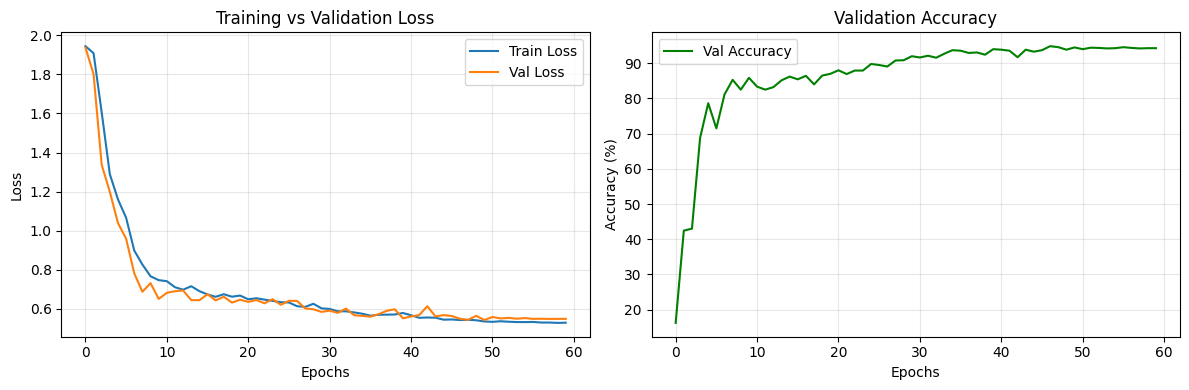

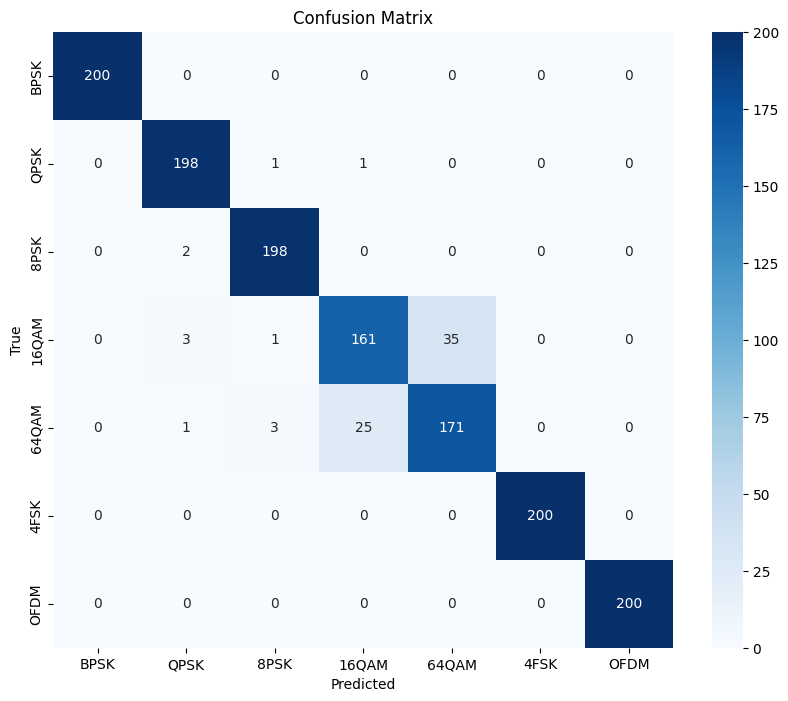


Classification Report:

              precision    recall  f1-score   support

        BPSK       1.00      1.00      1.00       200
        QPSK       0.97      0.99      0.98       200
        8PSK       0.98      0.99      0.98       200
       16QAM       0.86      0.81      0.83       200
       64QAM       0.83      0.85      0.84       200
        4FSK       1.00      1.00      1.00       200
        OFDM       1.00      1.00      1.00       200

    accuracy                           0.95      1400
   macro avg       0.95      0.95      0.95      1400
weighted avg       0.95      0.95      0.95      1400



In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# 1. Plot Training History
def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(history['val_acc'], label='Val Accuracy', color='green')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 2. Detailed Evaluation
def evaluate_model(model, val_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    # Inference loop
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

# --- RUN EVALUATION ---

# 1. Visualize Training Curves
plot_history(history)

# 2. Run Inference & Metrics
# Make sure 'modulations' list is defined from your earlier cell
if 'modulations' not in locals():
    modulations = ['BPSK', 'QPSK', '8PSK', '16QAM', '64QAM', '4FSK', 'OFDM']

evaluate_model(model_opt, val_loader, modulations)

In [ ]:
# # 1. Define Weights based on your report
# # Indexes: BPSK(0), QPSK(1), 8PSK(2), 16QAM(3), 64QAM(4), 4FSK(5), OFDM(6)
# # We give MASSIVE weight to class 4 (64QAM) and class 3 (16QAM)
# class_weights = torch.tensor([1.0, 2.0, 3.0, 3.0, 4.0, 1.0, 1.0]).to(device)

# # 2. Re-initialize Loss with Weights
# criterion_weighted = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# # 3. Load Phase 2 model (starting point)
# print("Loading Phase 2 model...")
# model_opt.load_state_dict(torch.load("best_rf_model_phase2.pth"))

# # 4. Phase 3 Training Loop (Weighted)
# print("Starting Phase 3: Weighted Fine-Tuning...")
# optimizer = torch.optim.AdamW(model_opt.parameters(), lr=0.00005, weight_decay=1e-4) # Very low LR
# scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

# for epoch in range(15): # 15 more epochs
#     model_opt.train()
#     running_loss = 0.0
    
#     for inputs, labels in train_loader:
#         inputs, labels = inputs.to(device), labels.to(device)
        
#         optimizer.zero_grad()
        
#         with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
#             outputs = model_opt(inputs)
#             loss = criterion_weighted(outputs, labels) # <--- USING WEIGHTED LOSS
        
#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()
        
#         running_loss += loss.item()

#     # Quick Val Check
#     if (epoch+1) % 5 == 0:
#         print(f"Phase 3 Epoch {epoch+1}/15 complete.")

# # 5. Final Save & Eval
# torch.save(model_opt.state_dict(), "best_rf_model_final.pth")
# print("\n--- FINAL WEIGHTED EVALUATION ---")
# evaluate_model(model_opt, val_loader, modulations)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_accuracy_by_snr(model, eng, modulations, snr_range):
    snr_accuracies = []
    
    print(f"Evaluating SNR range: {snr_range}...")
    
    model.eval()
    
    for snr in snr_range:
        correct = 0
        total = 0
        
        # Generate a mini-batch for this specific SNR
        # 50 samples per class per SNR point
        for label_idx, mod in enumerate(modulations):
            # Generate on the fly
            signal = generate_signal(eng, mod, snr_db=snr, num_symbols=1000)
            
            # Create a batch of 50
            batch_signals = []
            for _ in range(50):
                s = generate_signal(eng, mod, snr_db=snr, num_symbols=1000)
                batch_signals.append(prepare_1d_signal(s, target_length=2048))
            
            # Convert to Tensor
            X_batch = torch.FloatTensor(np.array(batch_signals)).to(device)
            y_batch = torch.LongTensor([label_idx] * 50).to(device)
            
            # Inference
            with torch.no_grad():
                outputs = model(X_batch)
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        
        acc = 100 * correct / total
        snr_accuracies.append(acc)
        print(f"SNR {snr}dB: {acc:.1f}%")
        
    return snr_accuracies

# Define SNR range to test (from noisy 0dB to clean 25dB)
snr_values = range(-5, 26, 2) 
accuracies = evaluate_accuracy_by_snr(model_opt, eng, modulations, snr_values)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(snr_values, accuracies, marker='o', linewidth=2, color='blue')
plt.title(f'Model Accuracy vs. SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.xticks(snr_values)
plt.axhline(y=90, color='r', linestyle='--', alpha=0.5, label='90% Target')
plt.legend()
plt.show()

Evaluating SNR range: range(-5, 26, 2)...


## Cleanup

In [ ]:
# Close MATLAB engine
eng.quit()
print("MATLAB engine closed.")

MATLAB engine closed.
